# MNIST Epoch별 수렴 속도 실험

이 노트북은 같은 하이퍼파라미터 조합을 유지한 채, 각 조합이 **epoch 1부터 20까지 얼마나 빠르게 높은 정확도에 도달하는지** 측정합니다.

원칙:

- `src/`, `REPORT.md`, 기존 노트북은 수정하지 않습니다.
- 각 조합은 20 epoch까지 한 번만 학습하고, 매 epoch 직후 loss와 validation accuracy를 기록합니다.
- validation accuracy 측정 시간은 학습 시간에 포함하지 않습니다.
- 최종 발표용 시간 비교는 이 노트북을 같은 머신, 같은 세션에서 실행한 결과만 사용합니다.


## 실험 질문

단순히 epoch 20의 최종 정확도만 비교하지 않고, 다음 질문에 답합니다.

- 어떤 조합이 가장 빨리 `98%` validation accuracy에 도달하는가?
- 최종 정확도가 비슷하다면 더 작은 모델 또는 더 짧은 학습 시간이 가능한가?
- loss curve와 accuracy curve가 빠르게 안정화되는 조합은 무엇인가?


In [1]:
from collections import OrderedDict
from pathlib import Path
import csv
import itertools
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from activations import ReLU, Softmax
from data import load_mnist
from layers import Affine, BatchNorm, Dropout
from losses import cross_entropy_loss
from optimizers import Adam, SGD

np.set_printoptions(precision=4, suppress=True)


## 실험 설정

`mnist_cost_accuracy_experiment.ipynb`와 같은 하이퍼파라미터 후보를 사용합니다.


In [2]:
SEED = 42
VALIDATION_SIZE = 10_000
BATCH_SIZE = 128
MAX_EPOCHS = 20

OPTIMIZER_LRS = {
    "SGD": [0.01, 0.05, 0.1],
    "Adam": [0.0005, 0.001],
}
DROPOUT_RATIOS = [0.0, 0.1, 0.2]
HIDDEN_SIZE_OPTIONS = [
    (512, 256),
    (384, 192),
    (256, 128),
]

VALIDATION_PASS_THRESHOLD = 98.0
SIMILAR_ACCURACY_GAP = 0.2
TEST_TOP_K = 3
TOP_CURVE_K = 5

SUMMARY_CSV_PATH = PROJECT_ROOT / "mnist_epoch_convergence_results.csv"
HISTORY_CSV_PATH = PROJECT_ROOT / "mnist_epoch_convergence_history.csv"

print("seed:", SEED)
print("max_epochs:", MAX_EPOCHS)
print("batch_size:", BATCH_SIZE)
print("optimizer/lr:", OPTIMIZER_LRS)
print("dropout:", DROPOUT_RATIOS)
print("hidden sizes:", HIDDEN_SIZE_OPTIONS)


seed: 42
max_epochs: 20
batch_size: 128
optimizer/lr: {'SGD': [0.01, 0.05, 0.1], 'Adam': [0.0005, 0.001]}
dropout: [0.0, 0.1, 0.2]
hidden sizes: [(512, 256), (384, 192), (256, 128)]


## 데이터 로드 및 분리

- train: 50,000개
- validation: 10,000개
- test: 10,000개

하이퍼파라미터 선택에는 validation만 사용하고, test accuracy는 최종 후보에만 계산합니다.


In [3]:
(x_train_full, y_train_full), (x_test, y_test) = load_mnist()

x_train = x_train_full[:-VALIDATION_SIZE]
y_train = y_train_full[:-VALIDATION_SIZE]
x_val = x_train_full[-VALIDATION_SIZE:]
y_val = y_train_full[-VALIDATION_SIZE:]

print("train:", x_train.shape, y_train.shape)
print("val:  ", x_val.shape, y_val.shape)
print("test: ", x_test.shape, y_test.shape)


train: (50000, 784) (50000,)
val:   (10000, 784) (10000,)
test:  (10000, 784) (10000,)


## 실험용 ConfigurableNetwork

`src/network.py`를 수정하지 않고, 노트북 내부에서만 hidden size를 바꿔 비교합니다. 기본 블록은 기존 모델과 같은 `Affine -> BatchNorm -> ReLU -> Dropout`입니다.


In [4]:
class ConfigurableNetwork:
    """노트북 실험 전용 MNIST 신경망."""

    def __init__(self, hidden_sizes=(512, 256), dropout_ratio=0.2):
        self.hidden_sizes = tuple(hidden_sizes)
        self.dropout_ratio = dropout_ratio
        self.params = {}

        layer_sizes = (784, *self.hidden_sizes, 10)
        for i in range(1, len(layer_sizes)):
            fan_in = layer_sizes[i - 1]
            fan_out = layer_sizes[i]
            self.params[f"W{i}"] = np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in)
            self.params[f"b{i}"] = np.zeros(fan_out)

        for i, hidden_size in enumerate(self.hidden_sizes, start=1):
            self.params[f"gamma{i}"] = np.ones(hidden_size)
            self.params[f"beta{i}"] = np.zeros(hidden_size)

        self.layers = OrderedDict()
        for i in range(1, len(layer_sizes) - 1):
            self.layers[f"Affine{i}"] = Affine(self.params[f"W{i}"], self.params[f"b{i}"])
            self.layers[f"BatchNorm{i}"] = BatchNorm(
                self.params[f"gamma{i}"],
                self.params[f"beta{i}"],
            )
            self.layers[f"ReLU{i}"] = ReLU()
            self.layers[f"Dropout{i}"] = Dropout(dropout_ratio)

        output_idx = len(layer_sizes) - 1
        self.layers[f"Affine{output_idx}"] = Affine(
            self.params[f"W{output_idx}"],
            self.params[f"b{output_idx}"],
        )
        self.softmax = Softmax()
        self.grads = {key: np.zeros_like(value) for key, value in self.params.items()}

    def forward(self, x, train=True):
        out = x
        for layer in self.layers.values():
            if isinstance(layer, (BatchNorm, Dropout)):
                out = layer.forward(out, train=train)
            else:
                out = layer.forward(out)
        return self.softmax.forward(out)

    def backward(self, dout):
        dout = self.softmax.backward(dout)
        for layer in reversed(self.layers.values()):
            dout = layer.backward(dout)

        affine_count = len(self.hidden_sizes) + 1
        for i in range(1, affine_count + 1):
            affine = self.layers[f"Affine{i}"]
            self.grads[f"W{i}"] = affine.dW
            self.grads[f"b{i}"] = affine.db

        for i in range(1, len(self.hidden_sizes) + 1):
            batchnorm = self.layers[f"BatchNorm{i}"]
            self.grads[f"gamma{i}"] = batchnorm.dgamma
            self.grads[f"beta{i}"] = batchnorm.dbeta

        return dout

    def predict(self, x):
        return self.forward(x, train=False)

    def total_params(self):
        return sum(param.size for param in self.params.values())


## 학습 및 평가 함수

`elapsed_sec`는 누적 학습 시간입니다. validation accuracy 계산 시간은 포함하지 않습니다.


In [5]:
def make_optimizer(name, lr):
    if name == "SGD":
        return SGD(lr=lr)
    if name == "Adam":
        return Adam(lr=lr)
    raise ValueError(f"unknown optimizer: {name}")


def accuracy(model, x, y, batch_size=1024):
    correct = 0
    total = x.shape[0]
    for start in range(0, total, batch_size):
        end = start + batch_size
        y_pred = model.predict(x[start:end])
        correct += np.sum(np.argmax(y_pred, axis=1) == y[start:end])
    return correct / total * 100


def train_one_epoch(model, optimizer, x, y, batch_size=128):
    indices = np.random.permutation(x.shape[0])
    epoch_loss = 0.0
    batch_count = 0

    for start in range(0, x.shape[0], batch_size):
        batch_indices = indices[start:start + batch_size]
        x_batch = x[batch_indices]
        y_batch = y[batch_indices]

        y_pred = model.forward(x_batch, train=True)
        loss = cross_entropy_loss(y_pred, y_batch)

        dout = y_pred.copy()
        dout[np.arange(x_batch.shape[0]), y_batch] -= 1
        dout /= x_batch.shape[0]

        model.backward(dout)
        optimizer.update(model.params, model.grads)

        epoch_loss += loss
        batch_count += 1

    return epoch_loss / batch_count


def make_config_id(config):
    hidden = "-".join(str(size) for size in config["hidden_sizes"])
    return f"{config['optimizer']}_lr{config['learning_rate']}_do{config['dropout']}_h{hidden}"


def make_label(row):
    return (
        f"{row['optimizer']} lr={row['learning_rate']} "
        f"do={row['dropout']} h={row['hidden_sizes']}"
    )


def run_experiment(config):
    np.random.seed(config["seed"])
    config_id = make_config_id(config)
    hidden_sizes_label = "-".join(str(size) for size in config["hidden_sizes"])
    model = ConfigurableNetwork(
        hidden_sizes=config["hidden_sizes"],
        dropout_ratio=config["dropout"],
    )
    optimizer = make_optimizer(config["optimizer"], config["learning_rate"])
    total_params = model.total_params()
    epoch_history = []
    elapsed_sec = 0.0

    for epoch in range(1, config["max_epochs"] + 1):
        started_at = time.perf_counter()
        train_loss = train_one_epoch(
            model,
            optimizer,
            x_train,
            y_train,
            batch_size=config["batch_size"],
        )
        elapsed_sec += time.perf_counter() - started_at
        validation_accuracy = accuracy(model, x_val, y_val)
        epoch_history.append({
            "config_id": config_id,
            "optimizer": config["optimizer"],
            "learning_rate": config["learning_rate"],
            "dropout": config["dropout"],
            "hidden_sizes": hidden_sizes_label,
            "total_params": total_params,
            "epoch": epoch,
            "train_loss": train_loss,
            "validation_accuracy": validation_accuracy,
            "elapsed_sec": elapsed_sec,
        })

    reached_rows = [
        row for row in epoch_history
        if row["validation_accuracy"] >= VALIDATION_PASS_THRESHOLD
    ]
    first_reached = reached_rows[0] if reached_rows else None
    best_row = max(epoch_history, key=lambda row: row["validation_accuracy"])
    final_row = epoch_history[-1]

    summary = {
        "config_id": config_id,
        "optimizer": config["optimizer"],
        "learning_rate": config["learning_rate"],
        "epochs": config["max_epochs"],
        "dropout": config["dropout"],
        "hidden_sizes": hidden_sizes_label,
        "total_params": total_params,
        "final_train_loss": final_row["train_loss"],
        "final_validation_accuracy": final_row["validation_accuracy"],
        "best_validation_accuracy": best_row["validation_accuracy"],
        "best_epoch": best_row["epoch"],
        "first_epoch_98": None if first_reached is None else first_reached["epoch"],
        "time_to_98_sec": None if first_reached is None else first_reached["elapsed_sec"],
        "final_elapsed_sec": final_row["elapsed_sec"],
        "test_accuracy": None,
        "model": model,
    }
    return summary, epoch_history


## 실험 후보 생성

총 후보 수는 기존 비용 대비 정확도 노트북과 같습니다.


In [6]:
experiment_configs = []
for optimizer_name, learning_rates in OPTIMIZER_LRS.items():
    for learning_rate, dropout, hidden_sizes in itertools.product(
        learning_rates,
        DROPOUT_RATIOS,
        HIDDEN_SIZE_OPTIONS,
    ):
        experiment_configs.append({
            "seed": SEED,
            "optimizer": optimizer_name,
            "learning_rate": learning_rate,
            "max_epochs": MAX_EPOCHS,
            "dropout": dropout,
            "hidden_sizes": hidden_sizes,
            "batch_size": BATCH_SIZE,
        })

print("total experiments:", len(experiment_configs))
for config in experiment_configs[:6]:
    print(config)


total experiments: 45
{'seed': 42, 'optimizer': 'SGD', 'learning_rate': 0.01, 'max_epochs': 20, 'dropout': 0.0, 'hidden_sizes': (512, 256), 'batch_size': 128}
{'seed': 42, 'optimizer': 'SGD', 'learning_rate': 0.01, 'max_epochs': 20, 'dropout': 0.0, 'hidden_sizes': (384, 192), 'batch_size': 128}
{'seed': 42, 'optimizer': 'SGD', 'learning_rate': 0.01, 'max_epochs': 20, 'dropout': 0.0, 'hidden_sizes': (256, 128), 'batch_size': 128}
{'seed': 42, 'optimizer': 'SGD', 'learning_rate': 0.01, 'max_epochs': 20, 'dropout': 0.1, 'hidden_sizes': (512, 256), 'batch_size': 128}
{'seed': 42, 'optimizer': 'SGD', 'learning_rate': 0.01, 'max_epochs': 20, 'dropout': 0.1, 'hidden_sizes': (384, 192), 'batch_size': 128}
{'seed': 42, 'optimizer': 'SGD', 'learning_rate': 0.01, 'max_epochs': 20, 'dropout': 0.1, 'hidden_sizes': (256, 128), 'batch_size': 128}


## 전체 실험 실행

이 셀은 실제 학습을 수행합니다. 각 조합마다 20 epoch까지 학습하며 매 epoch 결과를 저장합니다.


In [7]:
results = []
epoch_history = []

for idx, config in enumerate(experiment_configs, start=1):
    label = (
        f"[{idx:02d}/{len(experiment_configs)}] "
        f"{config['optimizer']} lr={config['learning_rate']} "
        f"dropout={config['dropout']} hidden={config['hidden_sizes']}"
    )
    print(label)
    summary, history = run_experiment(config)
    results.append(summary)
    epoch_history.extend(history)
    print(
        f"  final_val_acc={summary['final_validation_accuracy']:.2f}% "
        f"best_val_acc={summary['best_validation_accuracy']:.2f}%@{summary['best_epoch']} "
        f"time_to_98={summary['time_to_98_sec']} "
        f"final_time={summary['final_elapsed_sec']:.1f}s "
        f"params={summary['total_params']:,}"
    )


[01/45] SGD lr=0.01 dropout=0.0 hidden=(512, 256)
  final_val_acc=97.16% best_val_acc=97.16%@20 time_to_98=None final_time=66.0s params=537,354
[02/45] SGD lr=0.01 dropout=0.0 hidden=(384, 192)
  final_val_acc=97.15% best_val_acc=97.15%@20 time_to_98=None final_time=51.1s params=378,442
[03/45] SGD lr=0.01 dropout=0.0 hidden=(256, 128)
  final_val_acc=97.07% best_val_acc=97.07%@20 time_to_98=None final_time=35.1s params=235,914
[04/45] SGD lr=0.01 dropout=0.1 hidden=(512, 256)
  final_val_acc=96.92% best_val_acc=97.03%@19 time_to_98=None final_time=58.7s params=537,354
[05/45] SGD lr=0.01 dropout=0.1 hidden=(384, 192)
  final_val_acc=96.95% best_val_acc=96.95%@20 time_to_98=None final_time=46.4s params=378,442
[06/45] SGD lr=0.01 dropout=0.1 hidden=(256, 128)
  final_val_acc=96.70% best_val_acc=96.70%@20 time_to_98=None final_time=33.9s params=235,914
[07/45] SGD lr=0.01 dropout=0.2 hidden=(512, 256)
  final_val_acc=96.64% best_val_acc=96.67%@19 time_to_98=None final_time=65.1s params=

## 후보 선택

epoch 20 기준 최고 validation accuracy와 0.2%p 이내인 조합을 유사 정확도 후보로 보고, 그중 `98%`에 가장 빨리 도달한 조합을 우선합니다.


In [8]:
def format_optional(value, suffix=""):
    if value is None:
        return ""
    if isinstance(value, float):
        return f"{value:.2f}{suffix}"
    return f"{value}{suffix}"


def display_summary(rows, limit=None):
    visible_rows = rows if limit is None else rows[:limit]
    header = (
        "optimizer lr       dropout hidden     params    final_val best_val "
        "best_ep first98 t98_sec final_sec test"
    )
    print(header)
    print("-" * len(header))
    for row in visible_rows:
        print(
            f"{row['optimizer']:<9} "
            f"{row['learning_rate']:<8} "
            f"{row['dropout']:<7} "
            f"{row['hidden_sizes']:<10} "
            f"{row['total_params']:>8,} "
            f"{row['final_validation_accuracy']:>8.2f}% "
            f"{row['best_validation_accuracy']:>7.2f}% "
            f"{row['best_epoch']:>7} "
            f"{format_optional(row['first_epoch_98']):>7} "
            f"{format_optional(row['time_to_98_sec']):>7} "
            f"{row['final_elapsed_sec']:>9.1f} "
            f"{format_optional(row['test_accuracy'], '%'):>7}"
        )


sorted_by_final = sorted(
    results,
    key=lambda row: (-row["final_validation_accuracy"], row["final_elapsed_sec"], row["total_params"]),
)
display_summary(sorted_by_final, limit=15)

if results:
    best_final_val = max(row["final_validation_accuracy"] for row in results)
    similar_results = [
        row for row in results
        if best_final_val - row["final_validation_accuracy"] <= SIMILAR_ACCURACY_GAP
    ]
else:
    best_final_val = None
    similar_results = []

reached_98_similar = [row for row in similar_results if row["time_to_98_sec"] is not None]
if reached_98_similar:
    final_candidates = sorted(
        reached_98_similar,
        key=lambda row: (row["time_to_98_sec"], row["total_params"], -row["final_validation_accuracy"]),
    )
else:
    final_candidates = sorted(
        similar_results,
        key=lambda row: (row["final_elapsed_sec"], row["total_params"], -row["final_validation_accuracy"]),
    )

print("\nsimilar accuracy candidates:", len(similar_results))
print("similar candidates reached 98%:", len(reached_98_similar))
if final_candidates:
    print("\nfinal candidates:")
    display_summary(final_candidates[:5])
else:
    print("No candidates. Run experiments first.")


optimizer lr       dropout hidden     params    final_val best_val best_ep first98 t98_sec final_sec test
---------------------------------------------------------------------------------------------------------
Adam      0.001    0.2     256-128     235,914    98.41%   98.41%      20       6   11.80      40.0        
Adam      0.0005   0.2     256-128     235,914    98.40%   98.40%      20       9   20.04      43.6        
Adam      0.0005   0.2     512-256     537,354    98.36%   98.37%      16       7   24.80      71.3        
Adam      0.001    0.2     512-256     537,354    98.34%   98.45%      17       5   19.34      77.3        
Adam      0.001    0.2     384-192     378,442    98.33%   98.36%      16       6   17.14      56.5        
Adam      0.0005   0.2     384-192     378,442    98.33%   98.33%      20       8   21.71      95.4        
SGD       0.1      0.2     512-256     537,354    98.28%   98.33%      19       8   24.48      57.9        
Adam      0.0005   0.1     256-1

## 최종 후보 Test Accuracy 계산

test set은 최종 후보 확인에만 사용합니다. 기본값은 상위 3개 후보입니다.


In [9]:
for row in final_candidates[:TEST_TOP_K]:
    if row["test_accuracy"] is None:
        row["test_accuracy"] = accuracy(row["model"], x_test, y_test)

if final_candidates:
    print("final candidates with test accuracy:")
    display_summary(final_candidates[:TEST_TOP_K])
else:
    print("No final candidates to test.")


final candidates with test accuracy:
optimizer lr       dropout hidden     params    final_val best_val best_ep first98 t98_sec final_sec test
---------------------------------------------------------------------------------------------------------
Adam      0.001    0.2     256-128     235,914    98.41%   98.41%      20       6   11.80      40.0  98.27%
Adam      0.001    0.2     384-192     378,442    98.33%   98.36%      16       6   17.14      56.5  98.09%
Adam      0.0005   0.1     256-128     235,914    98.24%   98.28%      17       9   17.97      39.8  98.03%


## CSV 저장

- `mnist_epoch_convergence_results.csv`: 조합별 최종 요약
- `mnist_epoch_convergence_history.csv`: epoch별 loss, validation accuracy, 누적 학습 시간


In [10]:
SUMMARY_COLUMNS = [
    "config_id",
    "optimizer",
    "learning_rate",
    "epochs",
    "dropout",
    "hidden_sizes",
    "total_params",
    "final_train_loss",
    "final_validation_accuracy",
    "best_validation_accuracy",
    "best_epoch",
    "first_epoch_98",
    "time_to_98_sec",
    "final_elapsed_sec",
    "test_accuracy",
]

HISTORY_COLUMNS = [
    "config_id",
    "optimizer",
    "learning_rate",
    "dropout",
    "hidden_sizes",
    "total_params",
    "epoch",
    "train_loss",
    "validation_accuracy",
    "elapsed_sec",
]

with SUMMARY_CSV_PATH.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=SUMMARY_COLUMNS)
    writer.writeheader()
    for row in sorted_by_final:
        writer.writerow({column: row[column] for column in SUMMARY_COLUMNS})

with HISTORY_CSV_PATH.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=HISTORY_COLUMNS)
    writer.writeheader()
    for row in epoch_history:
        writer.writerow({column: row[column] for column in HISTORY_COLUMNS})

print("saved summary:", SUMMARY_CSV_PATH)
print("saved history:", HISTORY_CSV_PATH)


saved summary: /Users/donghyunkim/Documents/week13-team-03-mnist-lab/mnist_epoch_convergence_results.csv
saved history: /Users/donghyunkim/Documents/week13-team-03-mnist-lab/mnist_epoch_convergence_history.csv


## 전체 Validation Accuracy Curve

모든 조합의 epoch별 validation accuracy를 한 번에 봅니다. 선이 많기 때문에 optimizer별 색상과 낮은 투명도를 사용합니다.


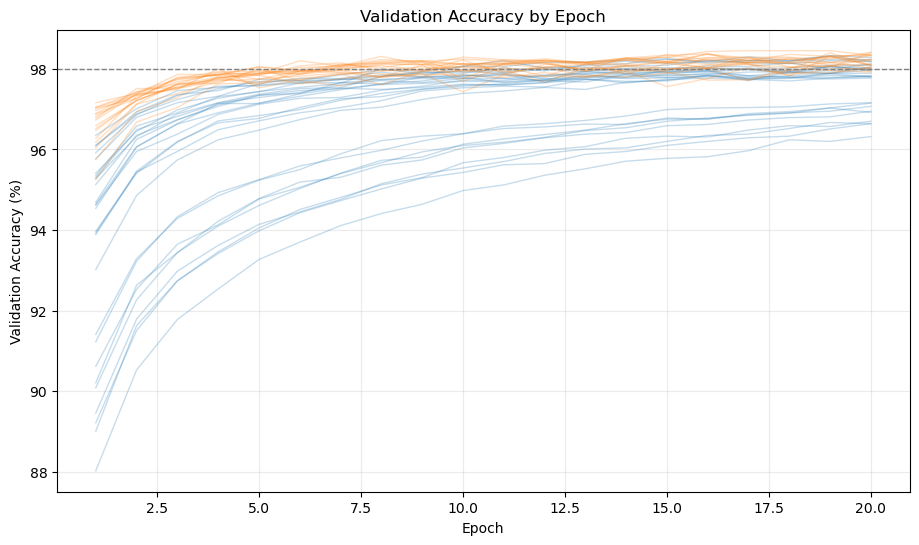

In [11]:
def rows_for_config(config_id):
    return [row for row in epoch_history if row["config_id"] == config_id]


if epoch_history:
    plt.figure(figsize=(11, 6))
    for summary in results:
        rows = rows_for_config(summary["config_id"])
        color = "tab:blue" if summary["optimizer"] == "SGD" else "tab:orange"
        plt.plot(
            [row["epoch"] for row in rows],
            [row["validation_accuracy"] for row in rows],
            color=color,
            alpha=0.25,
            linewidth=1,
        )
    plt.axhline(VALIDATION_PASS_THRESHOLD, color="gray", linestyle="--", linewidth=1)
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy (%)")
    plt.title("Validation Accuracy by Epoch")
    plt.grid(alpha=0.25)
    plt.show()
else:
    print("Run experiments first.")


## 상위 후보 Accuracy Curve

최종 후보 상위 5개만 표시해 누가 빨리 높은 정확도에 수렴하는지 비교합니다.


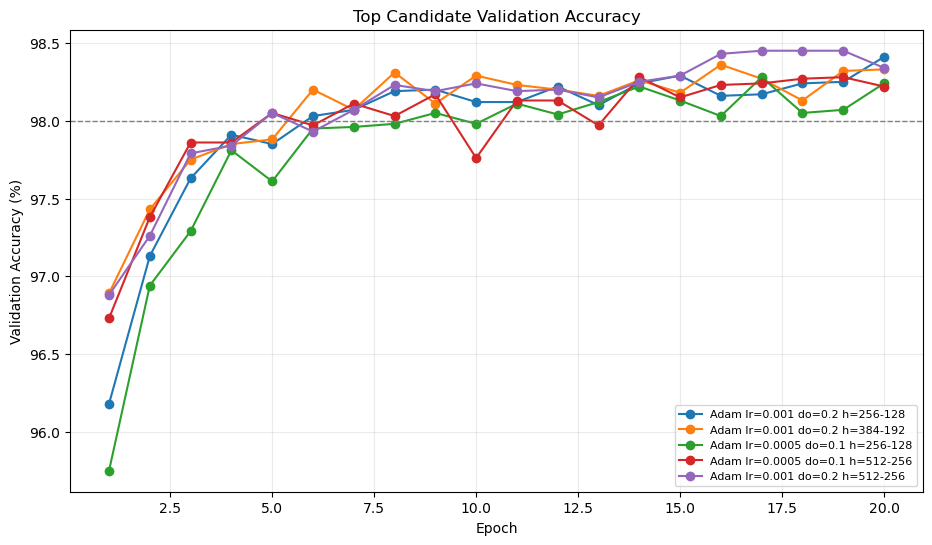

In [12]:
if final_candidates:
    plt.figure(figsize=(11, 6))
    for summary in final_candidates[:TOP_CURVE_K]:
        rows = rows_for_config(summary["config_id"])
        plt.plot(
            [row["epoch"] for row in rows],
            [row["validation_accuracy"] for row in rows],
            marker="o",
            label=make_label(summary),
        )
    plt.axhline(VALIDATION_PASS_THRESHOLD, color="gray", linestyle="--", linewidth=1)
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy (%)")
    plt.title("Top Candidate Validation Accuracy")
    plt.legend(fontsize=8)
    plt.grid(alpha=0.25)
    plt.show()
else:
    print("Select final candidates first.")


## 상위 후보 Train Loss Curve

정확도뿐 아니라 loss가 얼마나 빨리 낮아지는지도 함께 봅니다.


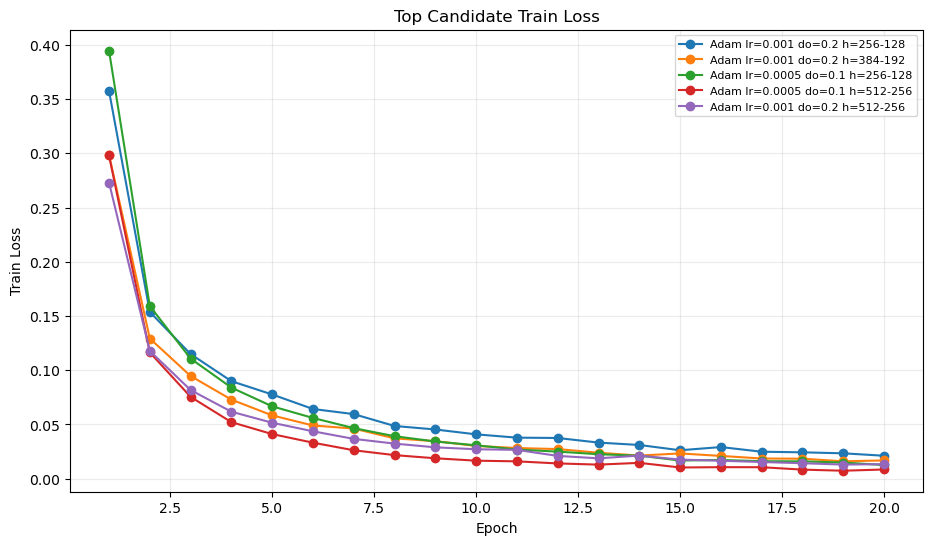

In [13]:
if final_candidates:
    plt.figure(figsize=(11, 6))
    for summary in final_candidates[:TOP_CURVE_K]:
        rows = rows_for_config(summary["config_id"])
        plt.plot(
            [row["epoch"] for row in rows],
            [row["train_loss"] for row in rows],
            marker="o",
            label=make_label(summary),
        )
    plt.xlabel("Epoch")
    plt.ylabel("Train Loss")
    plt.title("Top Candidate Train Loss")
    plt.legend(fontsize=8)
    plt.grid(alpha=0.25)
    plt.show()
else:
    print("Select final candidates first.")


## 누적 학습 시간 대비 Validation Accuracy

발표 주제에 가장 직접적으로 연결되는 그래프입니다. 왼쪽 위로 갈수록 적은 시간으로 높은 정확도에 도달한 조합입니다.


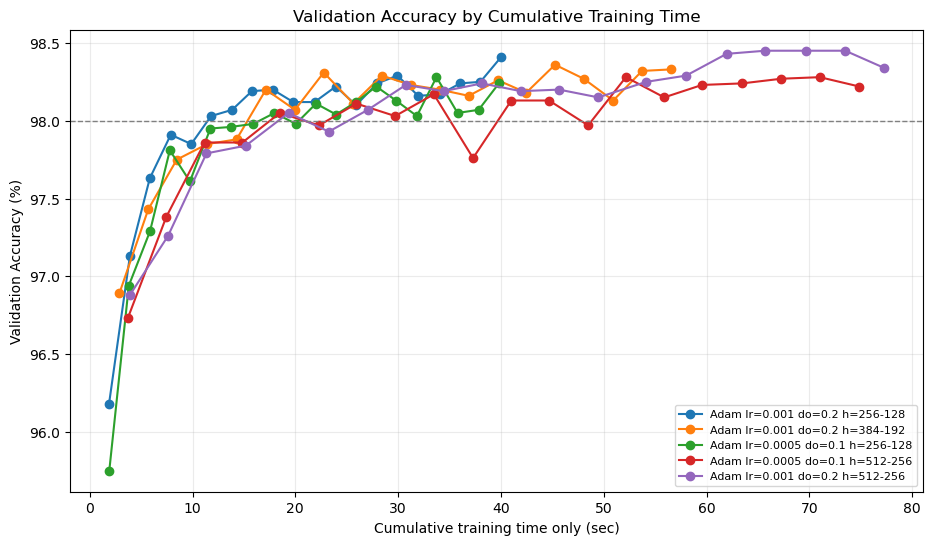

In [14]:
if final_candidates:
    plt.figure(figsize=(11, 6))
    for summary in final_candidates[:TOP_CURVE_K]:
        rows = rows_for_config(summary["config_id"])
        plt.plot(
            [row["elapsed_sec"] for row in rows],
            [row["validation_accuracy"] for row in rows],
            marker="o",
            label=make_label(summary),
        )
    plt.axhline(VALIDATION_PASS_THRESHOLD, color="gray", linestyle="--", linewidth=1)
    plt.xlabel("Cumulative training time only (sec)")
    plt.ylabel("Validation Accuracy (%)")
    plt.title("Validation Accuracy by Cumulative Training Time")
    plt.legend(fontsize=8)
    plt.grid(alpha=0.25)
    plt.show()
else:
    print("Select final candidates first.")


## 발표 결론 작성 템플릿

실험 후 아래 문장을 실제 숫자로 채웁니다.

- 같은 환경에서 재측정한 결과, epoch 20 기준 최고 validation accuracy는 `___%`였습니다.
- 최고 정확도와 `0.2%p` 이내인 유사 정확도 후보 중 `98%`에 가장 빨리 도달한 조합은 `___`였습니다.
- 이 조합은 `___ epoch`, `___ seconds` 만에 98%에 도달했습니다.
- 최종 test accuracy는 `___%`였고, 파라미터 수는 `___`개였습니다.
- 따라서 MNIST에서는 무조건 더 오래 학습하기보다, 빠르게 수렴하는 optimizer/lr/model size 조합을 찾는 것이 비용 대비 효율적이었습니다.
